<center><h1><b>ANALYSIS OF CUTS ON MC</b></h1></center>

In this notebook we want to search for the best cuts of the Monte Carlo data

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
import os

import gc
import itertools

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

# UPLOADING DATA

#### ALL OUR DATA

In [2]:
%%bash
ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

mc_pairs_001_010_pt1.pkl
mc_pairs_001_010_pt2.pkl
mc_pairs_001_010_pt3.pkl
mc_pairs_011_020_pt1.pkl
mc_pairs_011_020_pt2.pkl
mc_pairs_011_020_pt3.pkl
mc_pairs_011_020_pt4.pkl
mc_pairs_011_020_pt5.pkl
mc_pairs_011_020_pt6.pkl
mc_pairs_021_030_pt1.pkl
mc_pairs_021_030_pt2.pkl
mc_pairs_021_030_pt3.pkl
mc_pairs_021_030_pt4.pkl
mc_pairs_021_030_pt5.pkl
mc_pairs_031_040_pt1.pkl
mc_pairs_031_040_pt2.pkl
mc_pairs_031_040_pt3.pkl
mc_pairs_031_040_pt4.pkl
mc_pairs_031_040_pt5.pkl
mc_pairs_041_050_pt1.pkl
mc_pairs_041_050_pt2.pkl
mc_pairs_041_050_pt3.pkl
mc_pairs_041_050_pt4.pkl
mc_pairs_041_050_pt5.pkl
mc_pairs_16_09.pkl


#### CHOSEN FILES

In [3]:
# list of all files to load
files = [
    "mc_pairs_001_010_pt1.pkl",
    "mc_pairs_001_010_pt2.pkl",
    "mc_pairs_001_010_pt3.pkl",
    "mc_pairs_011_020_pt1.pkl",
    "mc_pairs_011_020_pt2.pkl",
    "mc_pairs_011_020_pt3.pkl",
    "mc_pairs_011_020_pt4.pkl",
    "mc_pairs_011_020_pt5.pkl",
    "mc_pairs_011_020_pt6.pkl",
    "mc_pairs_021_030_pt1.pkl",
    "mc_pairs_021_030_pt2.pkl",
    "mc_pairs_021_030_pt3.pkl",
    "mc_pairs_021_030_pt4.pkl",
    "mc_pairs_021_030_pt5.pkl",
    "mc_pairs_031_040_pt1.pkl",
    "mc_pairs_031_040_pt2.pkl",
    "mc_pairs_031_040_pt3.pkl",
    # "mc_pairs_031_040_pt4.pkl",
    # "mc_pairs_031_040_pt5.pkl",
    # "mc_pairs_041_050_pt1.pkl",
    # "mc_pairs_041_050_pt2.pkl",
    # "mc_pairs_041_050_pt3.pkl",
    # "mc_pairs_041_050_pt4.pkl",
    # "mc_pairs_041_050_pt5.pkl",
]

#### UPLOAD DATA

In [4]:
# directory where the files are stored
data_dir = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

# load each pickle into a DataFrame
final_results = []
for f in files:
    full_path = os.path.join(data_dir, f)
    df = pd.read_pickle(full_path)
    final_results.append(df)
    del df
print(f"Loaded {len(files)} files.")

# concatenate all DataFrames into one
final_results = pd.concat(final_results, ignore_index=True)

Loaded 17 files.


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 28_585_297 rows and 24 columns.
It occupies 5_234.12 MB


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,...,track_pdg_pos,track_pdg_neg,mother_pdg_pos,mother_pdg_neg,beauty_pdg_pos,beauty_pdg_neg,mother_N_final_state_pos,mother_N_final_state_neg,mother_orig_ind_pos,mother_orig_ind_neg
0,4.302637e-05,1.078002,0.965592,2.071664,0.008672,0.541366,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
1,-2.267289e-05,0.954106,0.976759,1.351086,0.017328,0.987720,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
2,-4.802854e-05,1.533463,1.549260,0.686016,6.203392,-0.249098,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
3,-4.880044e-07,1.353739,1.423982,0.511211,0.009233,-0.387148,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
4,3.675097e-05,1.292375,1.360894,0.652137,0.015217,-0.390342,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585292,5.258937e-02,0.666448,0.806590,0.842768,2.566516,0.629973,0.541465,-4.766050,-999.000000,-0.200726,...,321.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585293,3.713347e-02,0.883208,0.896981,1.166228,2.448712,0.298682,0.541465,-4.766050,-999.000000,-0.200726,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585294,4.271557e-02,0.819857,0.892104,1.001889,1.464870,0.204777,0.541465,-4.766050,-999.000000,-0.200726,...,321.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585295,5.897032e-03,1.522838,1.426583,0.619172,0.513109,-0.411187,0.473849,-6.739955,-999.000000,-0.021349,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585296,2.728765e-02,1.525444,1.396462,0.978039,3.265037,-0.391168,0.343846,-8.423986,-999.000000,-0.098791,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0


## TRUE $D_0$ IN OUR DATA

In [6]:
mask_true_d0 = (
    (final_results["track_pdg_pos"].isin([-321, 211])) &
    (final_results["track_pdg_neg"].isin([-321, 211])) &
    (final_results["mother_pdg_pos"] == 421) &
    (final_results["mother_pdg_neg"] == 421) &
    (final_results["beauty_pdg_pos"] == 0) &
    (final_results["beauty_pdg_neg"] == 0) &
    (final_results["mother_N_final_state_pos"] == 2) &
    (final_results["mother_N_final_state_neg"] == 2)
)
mask_true_anti_d0 = (
    (final_results["track_pdg_pos"].isin([321, -211])) &
    (final_results["track_pdg_neg"].isin([321, -211])) &
    (final_results["mother_pdg_pos"] == -421) &
    (final_results["mother_pdg_neg"] == -421) &
    (final_results["beauty_pdg_pos"] == 0) &
    (final_results["beauty_pdg_neg"] == 0) &
    (final_results["mother_N_final_state_pos"] == 2) &
    (final_results["mother_N_final_state_neg"] == 2)
)

In [7]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print("Rest:              ", len(final_results)-d0_tot-anti_d0_tot )
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       6345
Number of anti-D0:  6757
Rest:               28572195
Fraction of D0 and anti-D0 over total: 0.0458%


The variables we have to work with are:

In [8]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_pt', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY',
       'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'pos_fDcaXY', 'track_pdg_pos',
       'track_pdg_neg', 'mother_pdg_pos', 'mother_pdg_neg', 'beauty_pdg_pos',
       'beauty_pdg_neg', 'mother_N_final_state_pos',
       'mother_N_final_state_neg', 'mother_orig_ind_pos',
       'mother_orig_ind_neg'],
      dtype='object')


Example: the variable 'neg_TOFka' means the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which is a $K^-$ for the $D_0$ case, a $\pi^-$ for the $anti-D_0$ case, and something else in background case.

---

---

# INVARIANT MASS
We now plot the data, remembering to plot both the columns for mass and anti-mass.

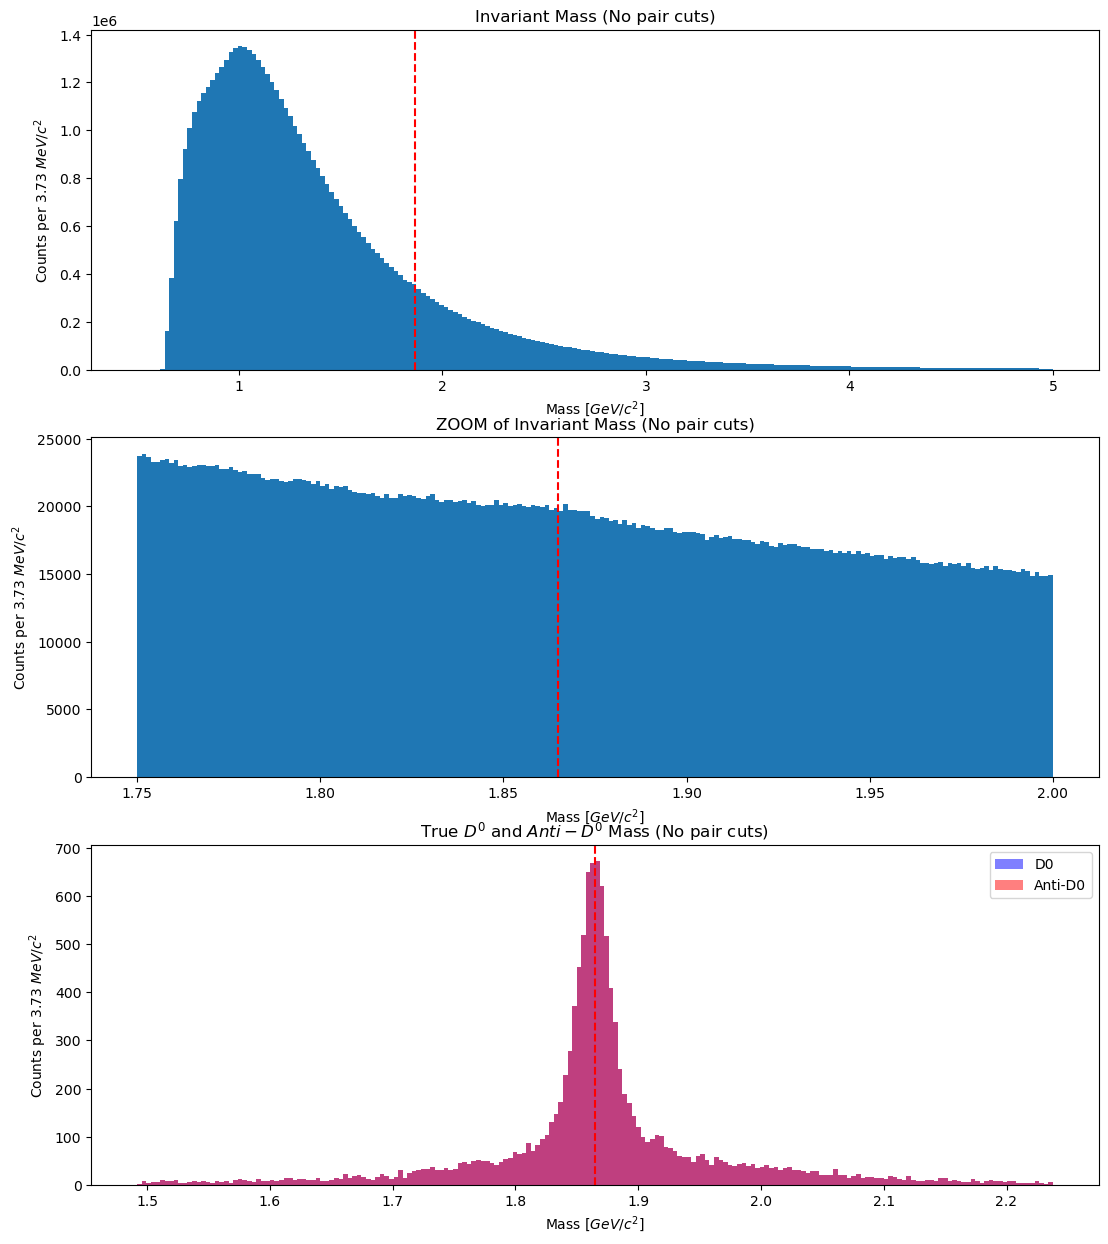

In [9]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 200

num_of_plots = 3
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,5*num_of_plots)  )

# GLOBAL PLOT
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values])
axs[0].hist( data, bins=N_BINS, range=(0.5, 5))
axs[0].axvline(x=m_d0, color="red", ls='--')
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No pair cuts)")
#axs[0].set_xticks( np.arange(0, 8) )

# ZOOM OF GLOBAL PLOT
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values] )
axs[1].hist( data, bins=N_BINS, range=(1.75, 2))
axs[1].axvline(x=m_d0, color="red", ls='--')
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("ZOOM of Invariant Mass (No pair cuts)")
#axs[1].set_xticks( np.arange(0, 8) )

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO
data = np.concatenate([ final_results.loc[mask_true_d0, "inv_mass"].values, final_results.loc[mask_true_d0, "anti_mass"].values ])
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = np.concatenate([final_results.loc[mask_true_d0, "inv_mass"].values, final_results.loc[mask_true_d0, "anti_mass"].values])
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--')
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title("True $D^0$ and $Anti-D^0$ Mass (No pair cuts)")
axs[2].legend()
#axs[2].set_xticks( np.arange(1.6, 2.2, 0.05) )

del data
#plt.savefig("D0_Mass_MC.png")
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.
Also the distribution of $D_0$ and $anti-D_0$ is exactly the same.

---

---

# VARIABLES DISTRIBUTION FOR TRUE $D_0$
Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $\pi$ TRACKS
Let's observe the distribution of the variables for the $\pi$ tracks.

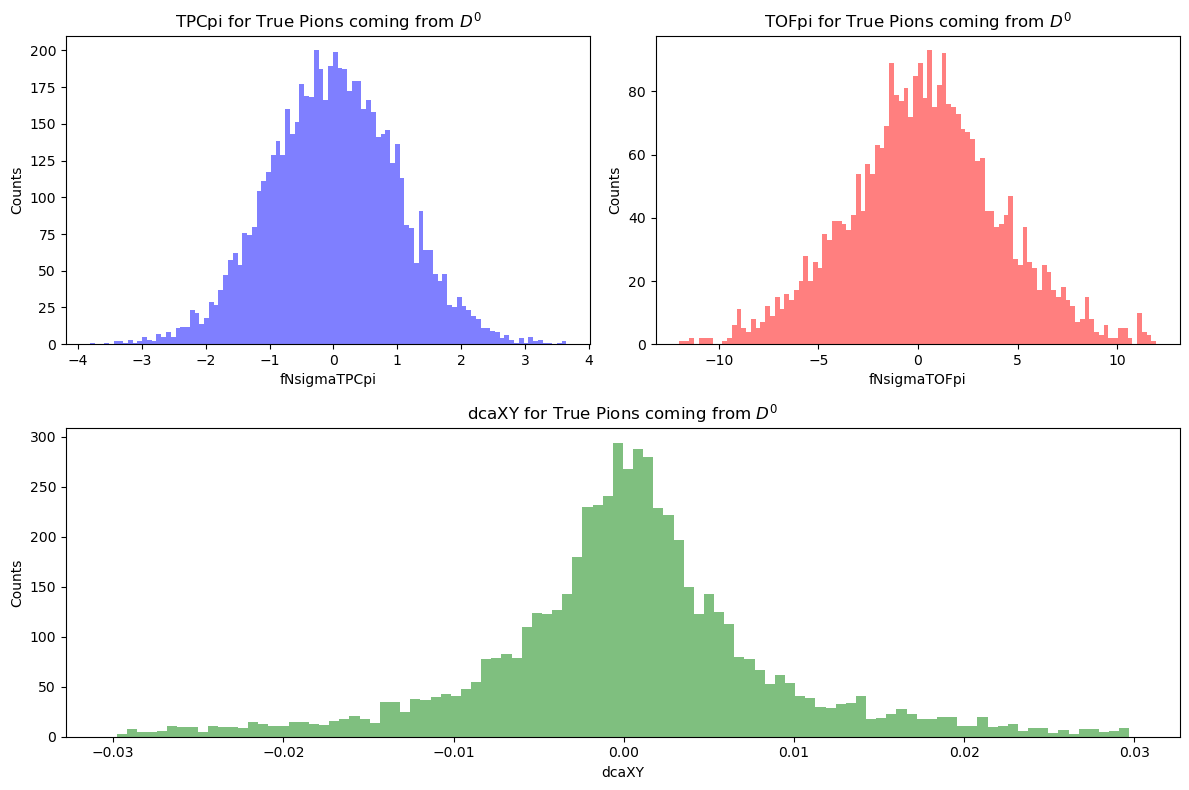

In [10]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi", "tofpi"],
    ["dcaxy","dcaxy"]
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 8)
)

# --- Plot TPCpi ---
data = final_results.loc[mask_true_d0, 'pos_TPCpi'].values
axes["tpcpi"].hist(data, bins=N_BINS, color="blue", alpha=0.5, label="D^0")
axes["tpcpi"].set_title("TPCpi for True Pions coming from $D^0$")
axes["tpcpi"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) ---
data = final_results.loc[mask_true_d0, 'pos_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi"].hist(data, bins=N_BINS, color="red", alpha=0.5, label="D^0")
axes["tofpi"].set_title("TOFpi for True Pions coming from $D^0$")
axes["tofpi"].set_xlabel("fNsigmaTOFpi")
axes["tofpi"].set_ylabel("Counts")

# --- Plot dcaXY ---
data = final_results.loc[mask_true_d0, 'pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy"].hist(data, bins=N_BINS, color="green", alpha=0.5, label=f"D^0")
axes["dcaxy"].set_title("dcaXY for True Pions coming from $D^0$")
axes["dcaxy"].set_xlabel("dcaXY")
axes["dcaxy"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $K$ TRACKS
Let's observe the distribution of the variables for the $Kaons$ tracks.

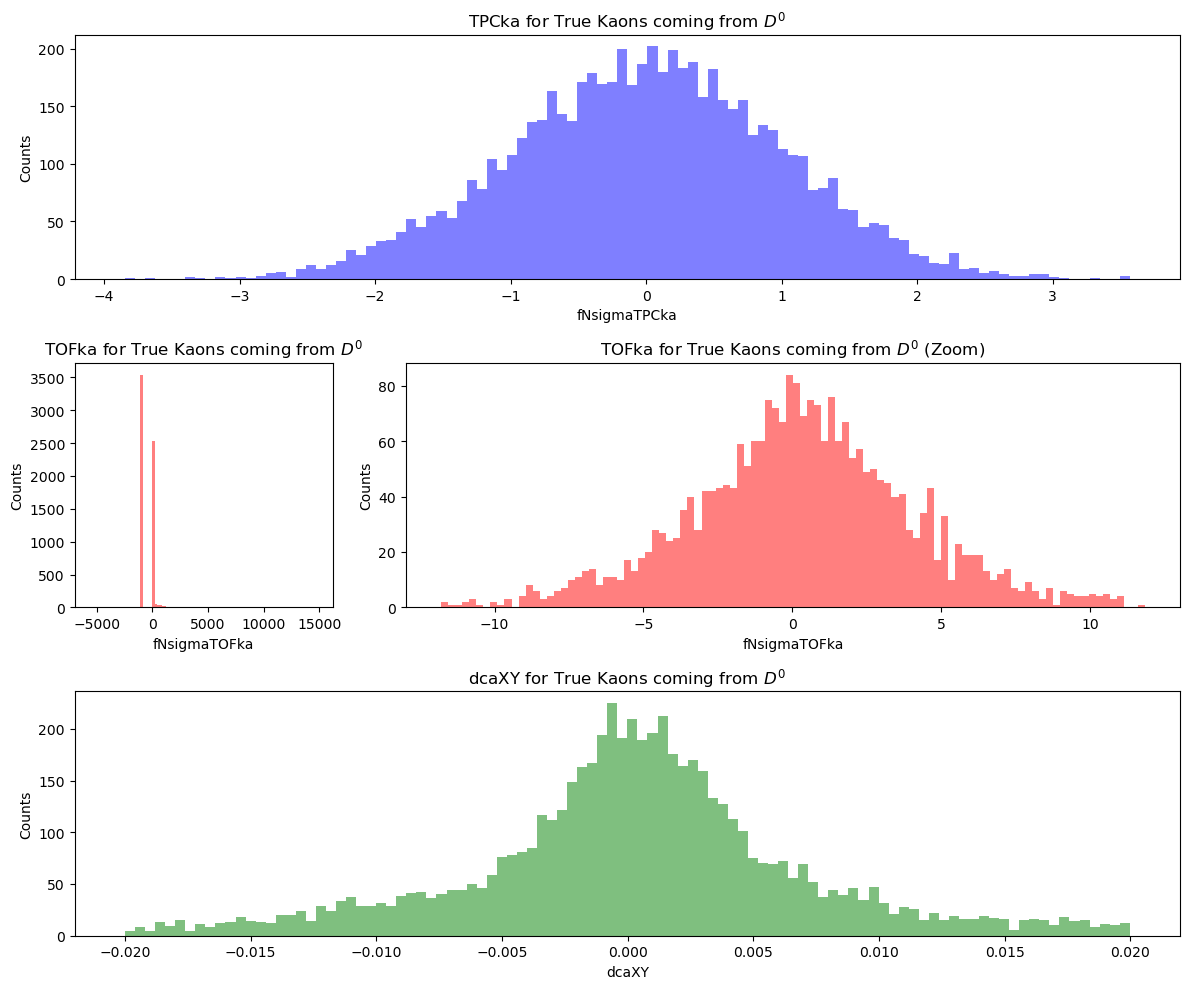

In [11]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka", "tpcka"],       # Riga superiore: un solo istogramma lungo
    ["tofka", "tofka_zoom"],  # Riga inferiore: due istogrammi affiancati
    ["dcaxy","dcaxy"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka ---
data = final_results.loc[mask_true_d0, 'neg_TPCka'].values
axes["tpcka"].hist(data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["tpcka"].set_title("TPCka for True Kaons coming from $D^0$")
axes["tpcka"].set_xlabel("fNsigmaTPCka")
axes["tpcka"].set_ylabel("Counts")

# --- Plot TOFka completo ---
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
axes["tofka"].hist(data, bins=N_BINS, color="red", alpha=0.5, label=f"D^0")
axes["tofka"].set_title("TOFka for True Kaons coming from $D^0$")
axes["tofka"].set_xlabel("fNsigmaTOFka")
axes["tofka"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5, label=f"D^0")
axes["tofka_zoom"].set_title("TOFka for True Kaons coming from $D^0$ (Zoom)")
axes["tofka_zoom"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom"].set_ylabel("Counts")

# --- Plot dcaXY ---
data = final_results.loc[mask_true_d0, 'neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy"].hist(data, bins=N_BINS, color="green", alpha=0.5, label=f"D^0")
axes["dcaxy"].set_title("dcaXY for True Kaons coming from $D^0$")
axes["dcaxy"].set_xlabel("dcaXY")
axes["dcaxy"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

### POYNTING ANGLE

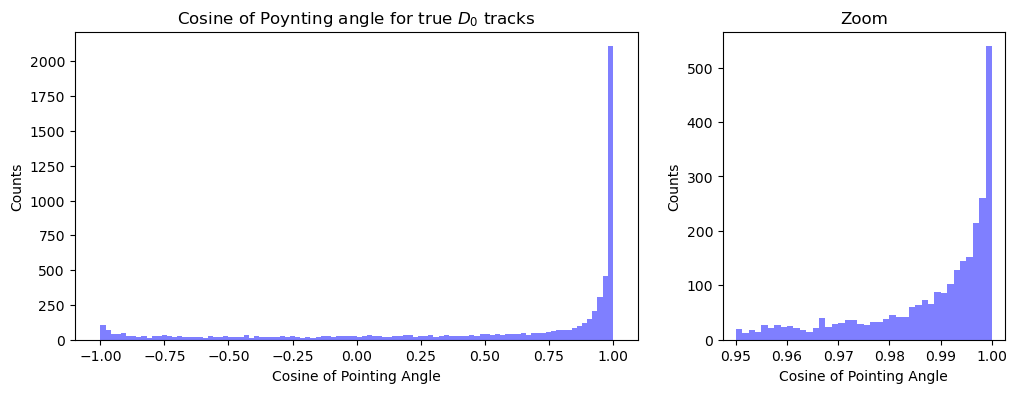

With the cut at 0.95 we keep 42.98% of original D_0s


In [49]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total", "zoom"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [2, 1]}
)

# --- Plot cosine of poynting angle ---
data = final_results.loc[mask_true_d0, 'cos_pointing'].values
axes["total"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total"].set_ylabel("Counts")
axes["total"].set_xlabel("Cosine of Pointing Angle")
axes["total"].set_title("Cosine of Poynting angle for true $D_0$ tracks")

# --- Zoom ---
cut = 0.95
data = data[ data > cut ]
axes["zoom"].hist( data, bins=40, color="blue", alpha=0.5, label=f"D^0")
axes["zoom"].set_ylabel("Counts")
axes["zoom"].set_xlabel("Cosine of Pointing Angle")
axes["zoom"].set_title("Zoom")

plt.show()

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D_0s")
del data

#### dcaXY PRODUCT

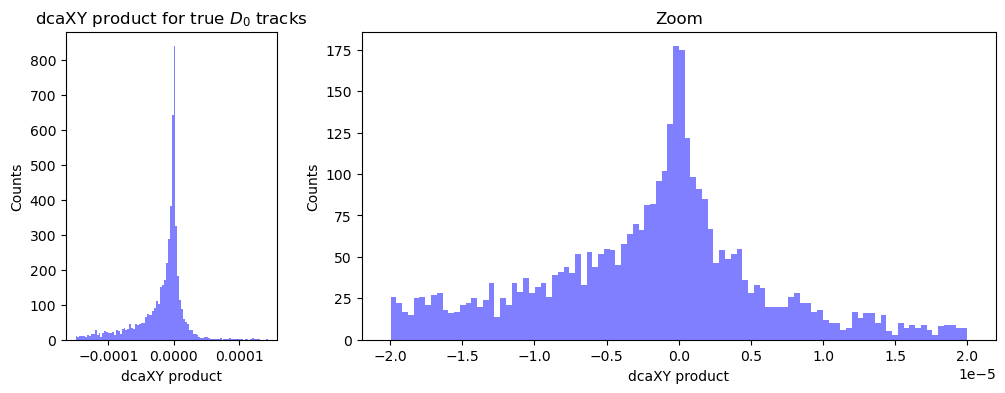

With the cut at 2e-05 we keep 57.18% of original D_0s


In [70]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total", "zoom"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot dcaCY product ---
data = final_results.loc[mask_true_d0, 'dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total"].set_ylabel("Counts")
axes["total"].set_xlabel("dcaXY product")
axes["total"].set_title("dcaXY product for true $D_0$ tracks")

# --- Zoom ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom"].hist( data, bins=100, color="blue", alpha=0.5, label=f"D^0")
axes["zoom"].set_ylabel("Counts")
axes["zoom"].set_xlabel("dcaXY product")
axes["zoom"].set_title("Zoom")

plt.show()

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D_0s")
del data

#### $p_T$ DISTRIBUTION

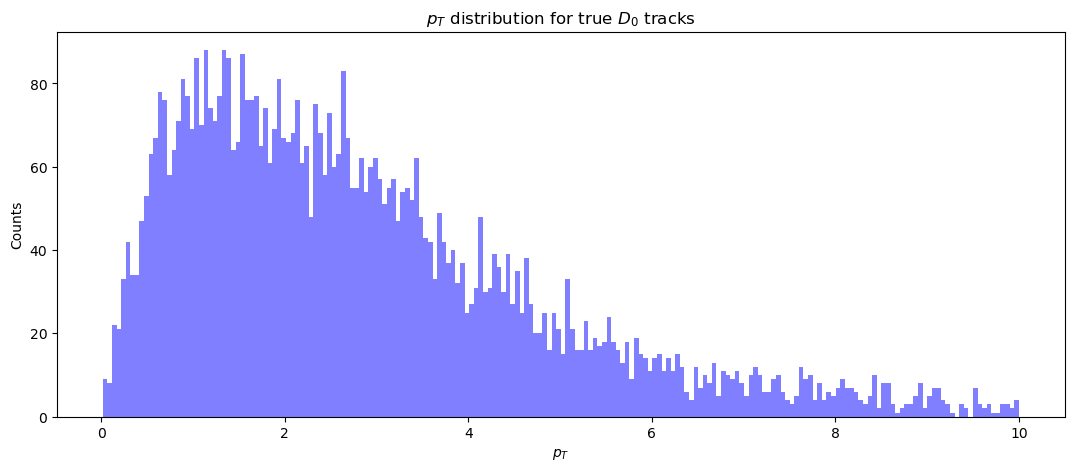

In [71]:
N_BINS = 200
fig, axs = plt.subplots( 1, 1, figsize=(13, 5)  )
data = final_results.loc[mask_true_d0, 'pt'].values
data = data [ data<10 ]
axs.hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0" )
axs.set_xlabel("$p_T$")
axs.set_ylabel("Counts")
axs.set_title("$p_T$ distribution for true $D_0$ tracks")
plt.show()

#### DECAY LENGTH

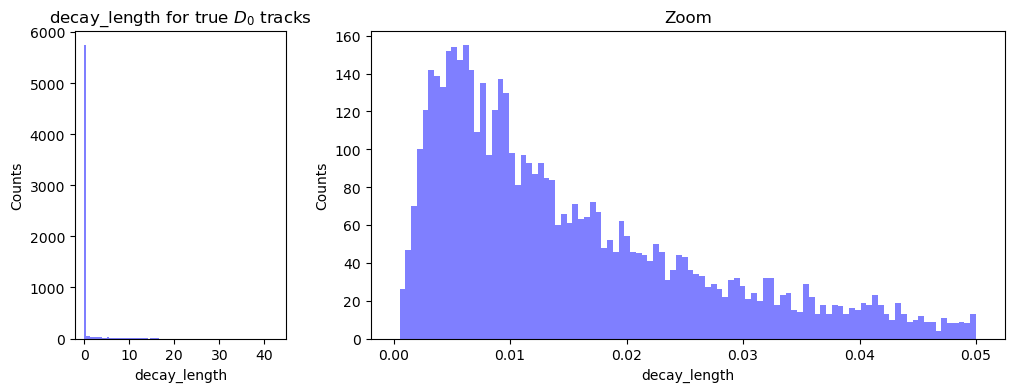

With the cut at 0.05 we keep 80.77% of original D_0s


In [72]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total", "zoom"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot decay length ---
data = final_results.loc[mask_true_d0, 'decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total"].set_ylabel("Counts")
axes["total"].set_xlabel("decay_length")
axes["total"].set_title("decay_length for true $D_0$ tracks")

# --- Zoom ---
cut = 0.05
data = data[ data < cut ]
axes["zoom"].hist( data, bins=100, color="blue", alpha=0.5, label=f"D^0")
axes["zoom"].set_ylabel("Counts")
axes["zoom"].set_xlabel("decay_length")
axes["zoom"].set_title("Zoom")

plt.show()

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D_0s")
del data